In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)


class NeuralNetArchitecture(nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.layer_1 = nn.Linear(in_dim, 12)
        self.layer_2 = nn.Linear(12, 10)
        self.layer_3 = nn.Linear(10, out_dim)

    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = self.layer_3(x)
        
        return x

In [155]:
def gibbs_duhem_loss(
    y_pred: torch.Tensor, y_true: torch.Tensor, X: torch.Tensor, lambda_gd: int = 1
) -> torch.Tensor:
    # MSE error
    mse_loss = torch.mean((y_pred - y_true) ** 2)

    # Gibbs Duhem loss
    gamma1 = y_pred[:, 0]
    dgamma1_dx1 = torch.autograd.grad(
        gamma1,
        X,
        grad_outputs=torch.ones_like(gamma1),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    gamma2 = y_pred[:, 1]
    dgamma2_dx2 = torch.autograd.grad(
        gamma2,
        X,
        grad_outputs=torch.ones_like(gamma2),
        create_graph=True,
        allow_unused=True,
    )[0][:, 5]

    gibbs_duhem_loss = torch.mean((dgamma1_dx1 + dgamma2_dx2) ** 2)

    # Total loss
    loss = mse_loss + gibbs_duhem_loss * lambda_gd
    return loss

In [156]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
data = pd.read_csv("C:/Projetos/biofuels-sciml/data/processed/toy_problem_input_dataset.csv").values

features = data[:, :-2]
labels = data[:, -2:]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

# Scale features
scaler = MinMaxScaler()
scaler.fit(X_train)

# Data to device
X_train_scaled = torch.tensor(
    scaler.transform(X_train), dtype=torch.float32, requires_grad=True
).to(device)
X_test_scaled = torch.tensor(
    scaler.transform(X_test), dtype=torch.float32, requires_grad=True
).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

# Hyperparameters
input_size = X_train_scaled.shape[1]
output_size = 2
num_epochs = 5000
learning_rate = 0.001
lambda_gd = 1e-1
patience = 500

# Model and optimizer
model = NeuralNetArchitecture(input_size, output_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Early stopping var
best_loss = float("inf")
epochs_no_improve = 0

# Plot data
epochs = []
custom_loss = []

In [157]:
# Training loop
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_scaled)

    # Loss
    loss = gibbs_duhem_loss(outputs, y_train, X_train_scaled, lambda_gd)

    # Backward propagation
    optimizer.zero_grad()
    loss.backward()

    # Update of model hyperparameters
    optimizer.step()

    # Append to plot list
    epochs.append(epoch + 1)
    custom_loss.append(loss.detach().item())

    # Evaluation
    if loss < best_loss:
        best_loss = loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

    if (epoch + 1) % 20 == 0:
        print(f"[epoch:{epoch + 1}]: The loss value for training step -> {loss}")

[epoch:20]: The loss value for training step -> 2.780892848968506
[epoch:40]: The loss value for training step -> 2.5681748390197754
[epoch:60]: The loss value for training step -> 2.299102544784546
[epoch:80]: The loss value for training step -> 1.8965531587600708
[epoch:100]: The loss value for training step -> 1.5383113622665405
[epoch:120]: The loss value for training step -> 1.328129529953003
[epoch:140]: The loss value for training step -> 1.2446303367614746
[epoch:160]: The loss value for training step -> 1.2111164331436157
[epoch:180]: The loss value for training step -> 1.188193678855896
[epoch:200]: The loss value for training step -> 1.1682156324386597
[epoch:220]: The loss value for training step -> 1.150370478630066
[epoch:240]: The loss value for training step -> 1.1340974569320679
[epoch:260]: The loss value for training step -> 1.1195919513702393
[epoch:280]: The loss value for training step -> 1.1069637537002563
[epoch:300]: The loss value for training step -> 1.096164

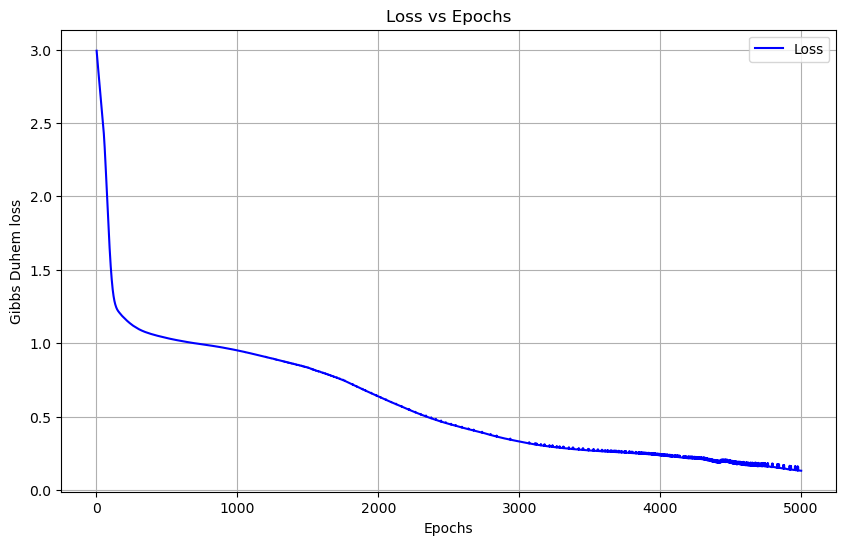

In [158]:
import matplotlib.pyplot as plt

# Plot training
plt.figure(figsize=(10, 6))
plt.plot(epochs, custom_loss, color="b", label="Loss")
plt.xlabel("Epochs")
plt.ylabel("Gibbs Duhem loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

In [159]:
# Evaluation
y_pred = model(X_test_scaled)
loss = gibbs_duhem_loss(y_pred, y_test, X_test_scaled, lambda_gd)

print(loss)

tensor(2.6528, device='cuda:0', grad_fn=<AddBackward0>)
